In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
df = pd.read_csv('normalizados_passo2.csv', parse_dates=['datetime'])

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

treino = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
validacao = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

for df in [treino, validacao]:
    df.drop(columns=['datetime','date','close','open','low','high','volume','average','amount_stock','id_ticker','business','AD_Line'], inplace=True)

X_train = treino.drop(columns=['trend'])  
y_train = treino['trend']  

X_valid = validacao.drop(columns=['trend'])  
y_valid = validacao['trend'] 

In [31]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

In [32]:
modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Acurácia do modelo 0 (fold): 0.6438
Acurácia do modelo 1 (fold): 0.6408
Acurácia do modelo 2 (fold): 0.6516
Acurácia do modelo 3 (fold): 0.6762
Acurácia do modelo 4 (fold): 0.6467
Acurácia do modelo 5 (fold): 0.6536
Acurácia do modelo 6 (fold): 0.6605
Acurácia do modelo 7 (fold): 0.6359
Acurácia do modelo 8 (fold): 0.6565
Acurácia média do Cross-Validation: 0.6517 ± 0.0113
Acurácia do conjunto de teste: 0.6155


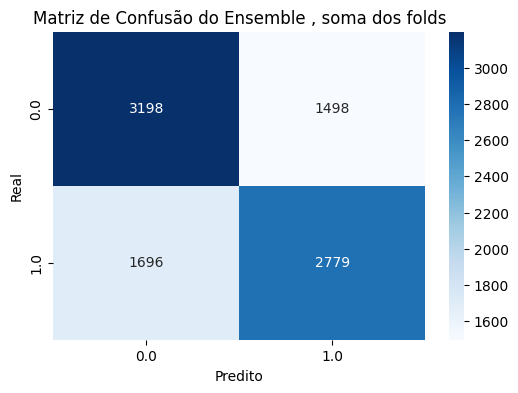

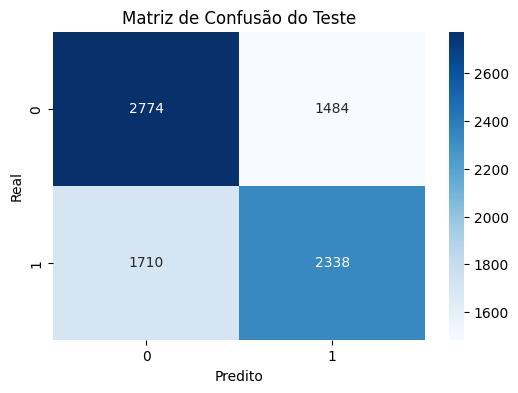

In [33]:
cv = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

modelos_treinados = []
scores = []
y_valid_total = []
y_pred_total = []

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):                
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    modelo_clone = clone(modelo)
    modelo_clone.fit(X_fold_train, y_fold_train)
    
    y_pred = modelo_clone.predict(X_fold_val)
    score = accuracy_score(y_fold_val, y_pred)
    
    modelos_treinados.append((f'modelo_{i}', modelo_clone))
    scores.append(score)

    print(f'Acurácia do modelo {i} (fold): {score:.4f}')

    y_valid_total.extend(y_fold_val)
    y_pred_total.extend(y_pred)

ensemble = VotingClassifier(estimators=modelos_treinados, voting='hard') 

ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_valid)
final_accuracy = accuracy_score(y_valid, y_pred_ensemble)

cm = confusion_matrix(y_valid_total, y_pred_total)

print(f'Acurácia média do Cross-Validation: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
print(f'Acurácia do conjunto de teste: {final_accuracy:.4f}')

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0.0", "1.0"], yticklabels=["0.0", "1.0"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão do Ensemble , soma dos folds")
plt.show()

matriz_confusao = confusion_matrix(y_valid, y_pred_ensemble)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_valid), yticklabels=np.unique(y_valid))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Teste')
plt.show()

In [34]:
print('Relatório de Classificação:')
print(classification_report(y_valid, y_pred_ensemble))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63      4258
           1       0.61      0.58      0.59      4048

    accuracy                           0.62      8306
   macro avg       0.62      0.61      0.61      8306
weighted avg       0.62      0.62      0.61      8306



In [35]:
importances = modelo.feature_importances_
feature_names = X_train.columns
sorted_indices = np.argsort(importances)[::-1]

for i in sorted_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


EMA_3: 0.0989
SMA_3: 0.0578
ADXR: 0.0493
Bollinger_Norm: 0.0485
EMA_5: 0.0476
SMA_5: 0.0471
std_close3: 0.0467
std_open3: 0.0452
std_close5: 0.0443
std_open5: 0.0431
std_open7: 0.0418
SMA_7: 0.0409
std_close7: 0.0397
SMA_9: 0.0397
std_open9: 0.0394
std_close11: 0.0390
EMA_11: 0.0390
std_close9: 0.0389
std_open11: 0.0387
SMA_11: 0.0386
EMA_7: 0.0379
EMA_9: 0.0378
